# Exploring the data of round 2

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [24]:
# Load Round 2 data
prices_m1 = pd.read_csv("../data/ROUND2/prices_round_2_day_-1.csv", sep=";")
prices_0  = pd.read_csv("../data/ROUND2/prices_round_2_day_0.csv", sep=";")
prices_1  = pd.read_csv("../data/ROUND2/prices_round_2_day_1.csv", sep=";")

trades_m1 = pd.read_csv("../data/ROUND2/trades_round_2_day_-1.csv", sep=";")
trades_0  = pd.read_csv("../data/ROUND2/trades_round_2_day_0.csv", sep=";")
trades_1  = pd.read_csv("../data/ROUND2/trades_round_2_day_1.csv", sep=";")

In [25]:
# Combine all days into one dataframe
prices = pd.concat(
    [
        prices_m1.assign(day=-1),
        prices_0.assign(day=0),
        prices_1.assign(day=1),
    ],
    ignore_index=True
)

trades = pd.concat(
    [
        trades_m1.assign(day=-1),
        trades_0.assign(day=0),
        trades_1.assign(day=1),
    ],
    ignore_index=True
)

display(prices.head())
display(trades.head())
print(prices["product"].unique())

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
1,-1,0,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0
2,-1,100,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
4,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,0,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9982.0,6,-1
1,3600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,3,-1
2,4200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10002.0,2,-1
3,4400,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11010.0,5,-1
4,5000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10996.0,5,-1


<StringArray>
['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Length: 2, dtype: str


In [26]:
# Create a global time axis so all 3 days can be plotted continuously
DAY_LENGTH = 1_000_000  # standard Prosperity convention for stitching days visually

prices["global_ts"] = prices["day"] * DAY_LENGTH + prices["timestamp"]
trades["global_ts"] = trades["day"] * DAY_LENGTH + trades["timestamp"]

prices = prices.sort_values(["product", "global_ts"]).reset_index(drop=True)
trades = trades.sort_values(["symbol", "global_ts"]).reset_index(drop=True)

In [27]:
# Quick helper to inspect one product
def get_product_df(product: str) -> pd.DataFrame:
    return prices[prices["product"] == product].copy()

for product in prices["product"].unique():
    df = get_product_df(product)
    print(product, len(df))

ASH_COATED_OSMIUM 30000
INTARIAN_PEPPER_ROOT 30000


In [28]:
def best_bid(row):
    bids = [row.get(f"bid_price_{i}", np.nan) for i in range(1, 4)]
    bids = [x for x in bids if pd.notna(x)]
    return max(bids) if bids else np.nan

def best_ask(row):
    asks = [row.get(f"ask_price_{i}", np.nan) for i in range(1, 4)]
    asks = [x for x in asks if pd.notna(x)]
    return min(asks) if asks else np.nan

def outer_bid(row):
    bids = [row.get(f"bid_price_{i}", np.nan) for i in range(1, 4)]
    bids = [x for x in bids if pd.notna(x)]
    return min(bids) if bids else np.nan

def outer_ask(row):
    asks = [row.get(f"ask_price_{i}", np.nan) for i in range(1, 4)]
    asks = [x for x in asks if pd.notna(x)]
    return max(asks) if asks else np.nan

def filtered_best_bid(row, min_size=10):
    candidates = []
    for i in range(1, 4):
        p = row.get(f"bid_price_{i}", np.nan)
        v = row.get(f"bid_volume_{i}", np.nan)
        if pd.notna(p) and pd.notna(v) and abs(v) >= min_size:
            candidates.append(p)
    if candidates:
        return max(candidates)
    return best_bid(row)

def filtered_best_ask(row, min_size=10):
    candidates = []
    for i in range(1, 4):
        p = row.get(f"ask_price_{i}", np.nan)
        v = row.get(f"ask_volume_{i}", np.nan)
        if pd.notna(p) and pd.notna(v) and abs(v) >= min_size:
            candidates.append(p)
    if candidates:
        return min(candidates)
    return best_ask(row)

def microprice(row):
    b = best_bid(row)
    a = best_ask(row)
    if pd.isna(b) or pd.isna(a):
        return np.nan
    
    bid_vol = np.nan
    ask_vol = np.nan
    
    for i in range(1, 4):
        if row.get(f"bid_price_{i}", np.nan) == b:
            bid_vol = abs(row.get(f"bid_volume_{i}", np.nan))
            break
    for i in range(1, 4):
        if row.get(f"ask_price_{i}", np.nan) == a:
            ask_vol = abs(row.get(f"ask_volume_{i}", np.nan))
            break
            
    if pd.isna(bid_vol) or pd.isna(ask_vol) or (bid_vol + ask_vol == 0):
        return (b + a) / 2
    
    return (b * ask_vol + a * bid_vol) / (bid_vol + ask_vol)

## Fair Value Proxy

In [29]:
def add_fair_value_proxies(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["best_bid"] = df.apply(best_bid, axis=1)
    df["best_ask"] = df.apply(best_ask, axis=1)
    df["outer_bid"] = df.apply(outer_bid, axis=1)
    df["outer_ask"] = df.apply(outer_ask, axis=1)

    df["mid"] = (df["best_bid"] + df["best_ask"]) / 2
    df["wall_mid_outer"] = (df["outer_bid"] + df["outer_ask"]) / 2

    df["filtered_best_bid"] = df.apply(lambda row: filtered_best_bid(row, min_size=10), axis=1)
    df["filtered_best_ask"] = df.apply(lambda row: filtered_best_ask(row, min_size=10), axis=1)
    df["filtered_mid"] = (df["filtered_best_bid"] + df["filtered_best_ask"]) / 2

    df["microprice"] = df.apply(microprice, axis=1)

    return df

prices_with_proxies = add_fair_value_proxies(prices)
display(prices_with_proxies.head())

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_ts,best_bid,best_ask,outer_bid,outer_ask,mid,wall_mid_outer,filtered_best_bid,filtered_best_ask,filtered_mid,microprice
0,-1,0,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0,-1000000,9982.0,10000.0,9982.0,10003.0,9991.0,9992.5,9982.0,10000.0,9991.0,9993.117647
1,-1,100,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0,-999900,9984.0,10000.0,9984.0,10003.0,9992.0,9993.5,9984.0,10000.0,9992.0,9992.000000
2,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0,-999800,9985.0,10001.0,9982.0,10001.0,9993.0,9991.5,9985.0,10001.0,9993.0,9993.000000
3,-1,300,ASH_COATED_OSMIUM,9982.0,27.0,NaN,NaN,NaN,NaN,10003.0,27.0,NaN,NaN,NaN,NaN,9992.5,0.0,-999700,9982.0,10003.0,9982.0,10003.0,9992.5,9992.5,9982.0,10003.0,9992.5,9992.500000
4,-1,400,ASH_COATED_OSMIUM,9995.0,8.0,9985.0,12.0,9983.0,25.0,10001.0,12.0,10004.0,25.0,NaN,NaN,9998.0,0.0,-999600,9995.0,10001.0,9983.0,10004.0,9998.0,9993.5,9985.0,10001.0,9993.0,9997.400000


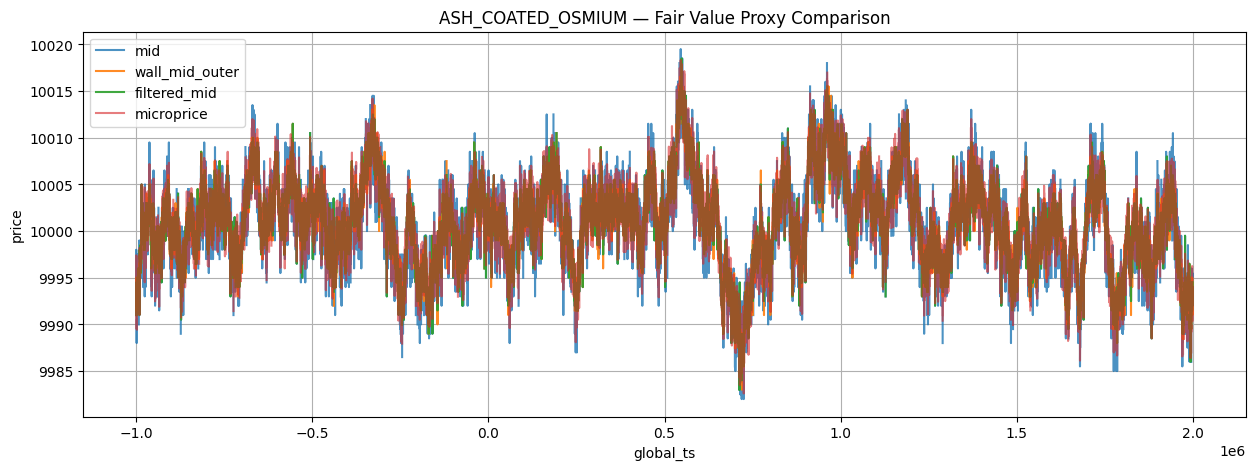

In [30]:
product = prices_with_proxies["product"].unique()[0]
df = prices_with_proxies[prices_with_proxies["product"] == product].copy()

plt.figure(figsize=(15, 5))
plt.plot(df["global_ts"], df["mid"], label="mid", alpha=0.8)
plt.plot(df["global_ts"], df["wall_mid_outer"], label="wall_mid_outer", alpha=0.9)
plt.plot(df["global_ts"], df["filtered_mid"], label="filtered_mid", alpha=0.9)
plt.plot(df["global_ts"], df["microprice"], label="microprice", alpha=0.6)
plt.title(f"{product} — Fair Value Proxy Comparison")
plt.xlabel("global_ts")
plt.ylabel("price")
plt.legend()
plt.show()

In [31]:
def proxy_stability_table(df: pd.DataFrame, product_col="product") -> pd.DataFrame:
    rows = []
    proxies = ["wall_mid_outer", "filtered_mid", "microprice", "mid"]

    for product in sorted(df[product_col].unique()):
        sub = df[df[product_col] == product].copy().sort_values("global_ts")

        for proxy in proxies:
            series = sub[proxy].dropna()
            diff = series.diff().dropna()

            rows.append({
                "Product": product,
                "Proxy": proxy,
                "Mean Abs Diff (1-step)": diff.abs().mean(),
                "Std Diff (1-step)": diff.std(),
                "Unique Values": series.nunique(),
                "NaN Count": sub[proxy].isna().sum(),
            })

    out = pd.DataFrame(rows)
    return out.sort_values(["Product", "Mean Abs Diff (1-step)"])

proxy_table = proxy_stability_table(prices_with_proxies)
display(proxy_table)

,Product,Proxy,Mean Abs Diff (1-step),Std Diff (1-step),Unique Values,NaN Count
0,ASH_COATED_OSMIUM,wall_mid_outer,0.780832,1.118643,64,2292
1,ASH_COATED_OSMIUM,filtered_mid,0.805681,1.176687,66,2292
2,ASH_COATED_OSMIUM,microprice,1.206344,1.770461,3159,2292
3,ASH_COATED_OSMIUM,mid,1.226982,1.881630,73,2292
4,INTARIAN_PEPPER_ROOT,wall_mid_outer,0.825470,1.224935,5934,2276
5,INTARIAN_PEPPER_ROOT,filtered_mid,0.879685,1.322043,5972,2276
6,INTARIAN_PEPPER_ROOT,microprice,0.980089,1.668936,13145,2276
7,INTARIAN_PEPPER_ROOT,mid,1.160841,1.887197,5962,2276


In [ ]:
def proxy_disagreement_table(df: pd.DataFrame, product_col="product") -> pd.DataFrame:
    rows = []
    comparisons = [
        ("mid", "filtered_mid"),
        ("mid", "microprice"),
        ("mid", "wall_mid_outer"),
        ("filtered_mid", "wall_mid_outer"),
    ]

    for product in sorted(df[product_col].unique()):
        sub = df[df[product_col] == product].copy()

        for a, b in comparisons:
            diff = (sub[a] - sub[b]).dropna()
            rows.append({
                "Product": product,
                "Comparison": f"{a} vs {b}",
                "Mean Difference": diff.abs().mean(),
                "Std Dev": diff.std(),
                "Max Difference": diff.abs().max(),
            })

    return pd.DataFrame(rows)

disagreement_table = proxy_disagreement_table(prices_with_proxies)
display(disagreement_table)

In [32]:
# Notebook conclusion template
proxy_table.sort_values(["Product", "Mean Abs Diff (1-step)"]).groupby("Product").first()

,Proxy,Mean Abs Diff (1-step),Std Diff (1-step),Unique Values,NaN Count
Product,,,,,
ASH_COATED_OSMIUM,wall_mid_outer,0.780832,1.118643,64,2292
INTARIAN_PEPPER_ROOT,wall_mid_outer,0.825470,1.224935,5934,2276


## Spread and Competition

In [33]:
def add_spread(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["spread"] = df["best_ask"] - df["best_bid"]
    df["mid"] = (df["best_bid"] + df["best_ask"]) / 2
    return df

spread_df = add_spread(prices_with_proxies)

In [34]:
def spread_stats(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    
    for product in sorted(df["product"].unique()):
        sub = df[df["product"] == product]
        
        rows.append({
            "Product": product,
            "Mean Spread": sub["spread"].mean(),
            "Median Spread": sub["spread"].median(),
            "Min Spread": sub["spread"].min(),
            "Max Spread": sub["spread"].max(),
            "Std Spread": sub["spread"].std(),
        })
        
    return pd.DataFrame(rows)

spread_stats_df = spread_stats(spread_df)
display(spread_stats_df)

,Product,Mean Spread,Median Spread,Min Spread,Max Spread,Std Spread
0,ASH_COATED_OSMIUM,16.234156,16.0,5.0,22.0,2.520303
1,INTARIAN_PEPPER_ROOT,14.121664,14.0,2.0,22.0,2.788202


In [35]:
def spread_structure(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    
    for product in sorted(df["product"].unique()):
        sub = df[df["product"] == product]
        total = len(sub)
        
        rows.append({
            "Product": product,
            "% Spread = 1": (sub["spread"] == 1).mean() * 100,
            "% Spread = 2": (sub["spread"] == 2).mean() * 100,
            "% Spread ≥ 3": (sub["spread"] >= 3).mean() * 100,
        })
        
    return pd.DataFrame(rows)

spread_structure_df = spread_structure(spread_df)
display(spread_structure_df)

,Product,% Spread = 1,% Spread = 2,% Spread ≥ 3
0,ASH_COATED_OSMIUM,0.0,0.000000,92.36
1,INTARIAN_PEPPER_ROOT,0.0,0.593333,91.82


In [36]:
def inside_spread_opportunity(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    
    for product in sorted(df["product"].unique()):
        sub = df[df["product"] == product]
        
        # You can step inside if spread >= 2
        inside_possible = (sub["spread"] >= 2).mean()
        
        rows.append({
            "Product": product,
            "Fraction Inside Quote Possible": inside_possible,
        })
        
    return pd.DataFrame(rows)

inside_df = inside_spread_opportunity(spread_df)
display(inside_df)

,Product,Fraction Inside Quote Possible
0,ASH_COATED_OSMIUM,0.923600
1,INTARIAN_PEPPER_ROOT,0.924133


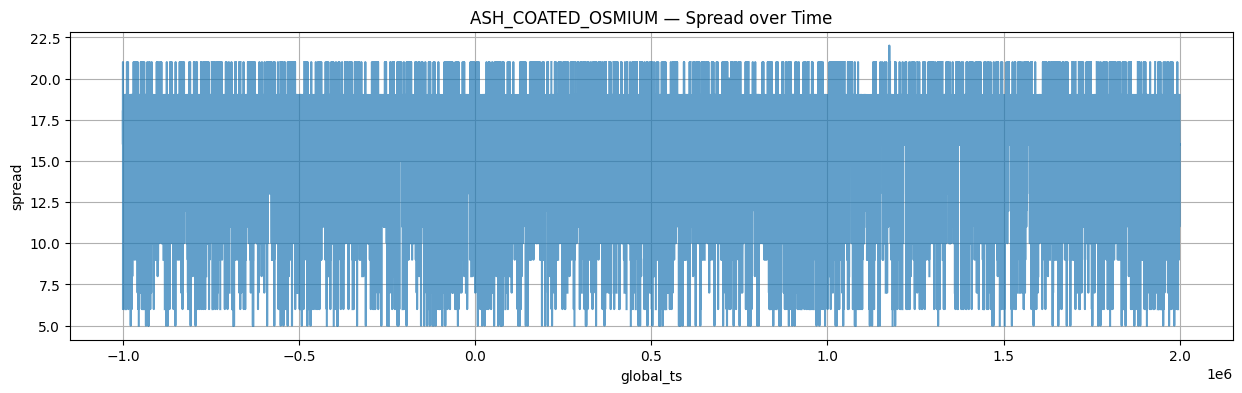

In [37]:
product = spread_df["product"].unique()[0]
df = spread_df[spread_df["product"] == product]

plt.figure(figsize=(15, 4))
plt.plot(df["global_ts"], df["spread"], alpha=0.7)
plt.title(f"{product} — Spread over Time")
plt.xlabel("global_ts")
plt.ylabel("spread")
plt.show()

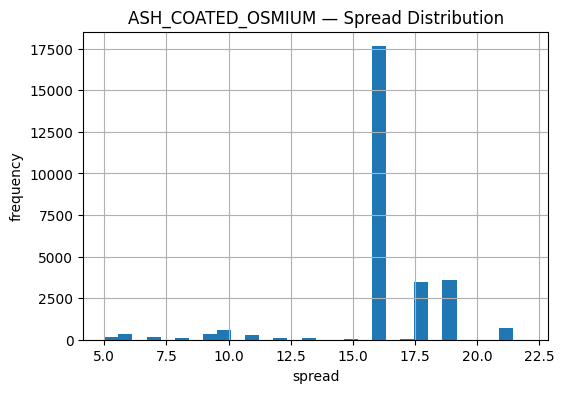

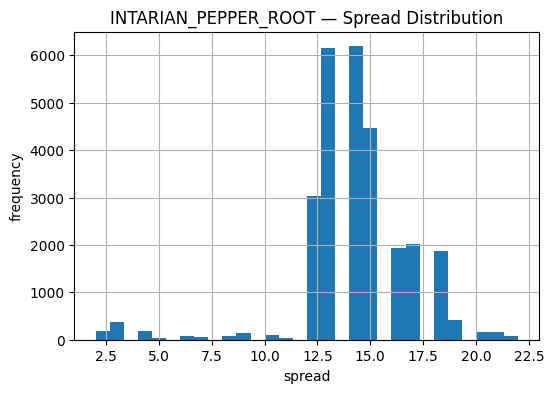

In [38]:
for product in spread_df["product"].unique():
    df = spread_df[spread_df["product"] == product]
    
    plt.figure(figsize=(6,4))
    plt.hist(df["spread"].dropna(), bins=30)
    plt.title(f"{product} — Spread Distribution")
    plt.xlabel("spread")
    plt.ylabel("frequency")
    plt.show()

## Fill probability vs quote aggressiveness

In [39]:
def simulate_fill_probability(df: pd.DataFrame, max_levels=5):
    results = []

    for product in df["product"].unique():
        sub = df[df["product"] == product].copy().reset_index(drop=True)

        for level in range(max_levels):
            buy_fills = []
            sell_fills = []

            for i in range(len(sub) - 1):
                row = sub.iloc[i]
                next_row = sub.iloc[i + 1]

                bid = row["best_bid"]
                ask = row["best_ask"]

                if pd.isna(bid) or pd.isna(ask):
                    continue

                # simulate quoting inside spread
                buy_price = bid + level
                sell_price = ask - level

                next_bid = next_row["best_bid"]
                next_ask = next_row["best_ask"]

                # Fill logic:
                # Buy gets filled if next ask <= our price
                buy_filled = next_ask <= buy_price if pd.notna(next_ask) else False

                # Sell gets filled if next bid >= our price
                sell_filled = next_bid >= sell_price if pd.notna(next_bid) else False

                buy_fills.append(buy_filled)
                sell_fills.append(sell_filled)

            results.append({
                "Product": product,
                "Level": level,
                "Buy Fill Rate": np.mean(buy_fills),
                "Sell Fill Rate": np.mean(sell_fills),
            })

    return pd.DataFrame(results)

fill_df = simulate_fill_probability(spread_df, max_levels=6)
display(fill_df)

,Product,Level,Buy Fill Rate,Sell Fill Rate
0,ASH_COATED_OSMIUM,0,0.000253,0.000433
1,ASH_COATED_OSMIUM,1,0.000289,0.000433
2,ASH_COATED_OSMIUM,2,0.000289,0.000433
3,ASH_COATED_OSMIUM,3,0.000361,0.000541
4,ASH_COATED_OSMIUM,4,0.000758,0.001155
5,ASH_COATED_OSMIUM,5,0.006208,0.006208
6,INTARIAN_PEPPER_ROOT,0,0.000794,0.000252
7,INTARIAN_PEPPER_ROOT,1,0.000794,0.000252
8,INTARIAN_PEPPER_ROOT,2,0.005555,0.007864
9,INTARIAN_PEPPER_ROOT,3,0.018180,0.020416


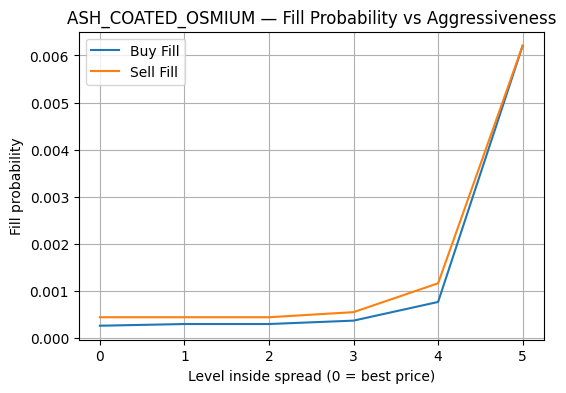

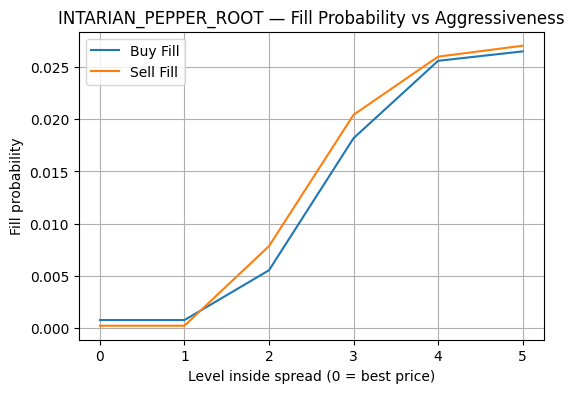

In [40]:
for product in fill_df["Product"].unique():
    sub = fill_df[fill_df["Product"] == product]

    plt.figure(figsize=(6,4))
    plt.plot(sub["Level"], sub["Buy Fill Rate"], label="Buy Fill")
    plt.plot(sub["Level"], sub["Sell Fill Rate"], label="Sell Fill")
    plt.title(f"{product} — Fill Probability vs Aggressiveness")
    plt.xlabel("Level inside spread (0 = best price)")
    plt.ylabel("Fill probability")
    plt.legend()
    plt.show()

In [41]:
def expected_value_analysis(df: pd.DataFrame, fill_df: pd.DataFrame):
    rows = []

    for product in df["product"].unique():
        sub = df[df["product"] == product]

        avg_spread = sub["spread"].mean()

        for _, row in fill_df[fill_df["Product"] == product].iterrows():
            level = row["Level"]

            # Approx profit per fill
            # If you quote inside, you capture spread minus distance
            profit_per_fill = avg_spread - 2 * level

            expected_buy = row["Buy Fill Rate"] * profit_per_fill
            expected_sell = row["Sell Fill Rate"] * profit_per_fill

            rows.append({
                "Product": product,
                "Level": level,
                "Expected Buy Value": expected_buy,
                "Expected Sell Value": expected_sell,
            })

    return pd.DataFrame(rows)

ev_df = expected_value_analysis(spread_df, fill_df)
display(ev_df)

,Product,Level,Expected Buy Value,Expected Sell Value
0,ASH_COATED_OSMIUM,0,0.004101,0.007031
1,ASH_COATED_OSMIUM,1,0.004110,0.006165
2,ASH_COATED_OSMIUM,2,0.003532,0.005299
3,ASH_COATED_OSMIUM,3,0.003694,0.005541
4,ASH_COATED_OSMIUM,4,0.006241,0.009510
5,ASH_COATED_OSMIUM,5,0.038701,0.038701
6,INTARIAN_PEPPER_ROOT,0,0.011206,0.003566
7,INTARIAN_PEPPER_ROOT,1,0.009619,0.003061
8,INTARIAN_PEPPER_ROOT,2,0.056225,0.079592
9,INTARIAN_PEPPER_ROOT,3,0.147651,0.165814


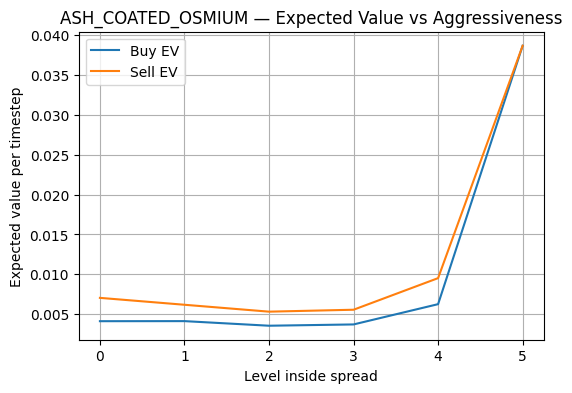

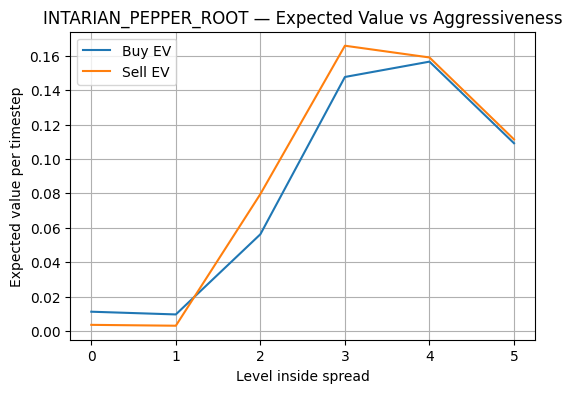

In [42]:
for product in ev_df["Product"].unique():
    sub = ev_df[ev_df["Product"] == product]

    plt.figure(figsize=(6,4))
    plt.plot(sub["Level"], sub["Expected Buy Value"], label="Buy EV")
    plt.plot(sub["Level"], sub["Expected Sell Value"], label="Sell EV")
    plt.title(f"{product} — Expected Value vs Aggressiveness")
    plt.xlabel("Level inside spread")
    plt.ylabel("Expected value per timestep")
    plt.legend()
    plt.show()

## Queue position/ execution quality

In [48]:
def collect_fill_times(df: pd.DataFrame, level=3, max_horizon=10, side="buy"):
    out = {}

    for product in df["product"].unique():
        sub = df[df["product"] == product].copy().reset_index(drop=True)
        times = []

        for i in range(len(sub) - max_horizon):
            row = sub.iloc[i]
            bid = row["best_bid"]
            ask = row["best_ask"]

            if pd.isna(bid) or pd.isna(ask):
                continue

            if side == "buy":
                quote_price = bid + level
                for h in range(1, max_horizon + 1):
                    future_ask = sub.iloc[i + h]["best_ask"]
                    if pd.notna(future_ask) and future_ask <= quote_price:
                        times.append(h)
                        break

            elif side == "sell":
                quote_price = ask - level
                for h in range(1, max_horizon + 1):
                    future_bid = sub.iloc[i + h]["best_bid"]
                    if pd.notna(future_bid) and future_bid >= quote_price:
                        times.append(h)
                        break

        out[product] = times

    return out

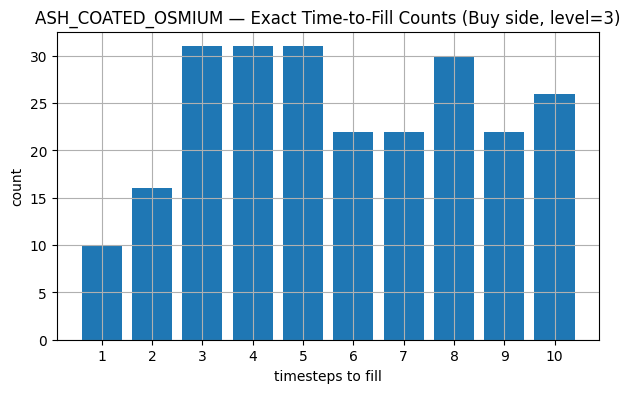

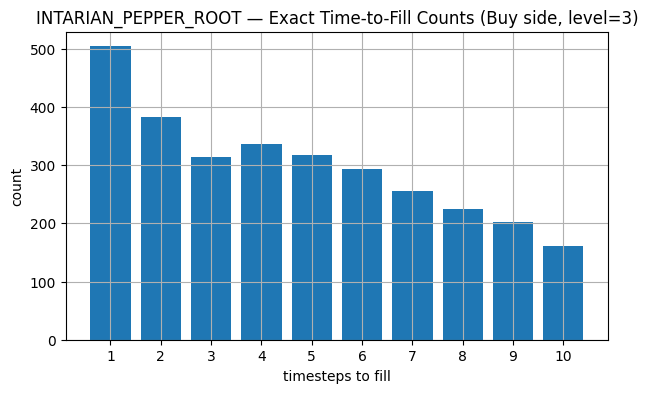

In [49]:
buy_fill_times = collect_fill_times(spread_df, level=3, max_horizon=10, side="buy")

for product, times in buy_fill_times.items():
    counts = pd.Series(times).value_counts().sort_index()

    plt.figure(figsize=(7, 4))
    plt.bar(counts.index, counts.values, width=0.8)
    plt.title(f"{product} — Exact Time-to-Fill Counts (Buy side, level=3)")
    plt.xlabel("timesteps to fill")
    plt.ylabel("count")
    plt.xticks(range(1, 11))
    plt.show()

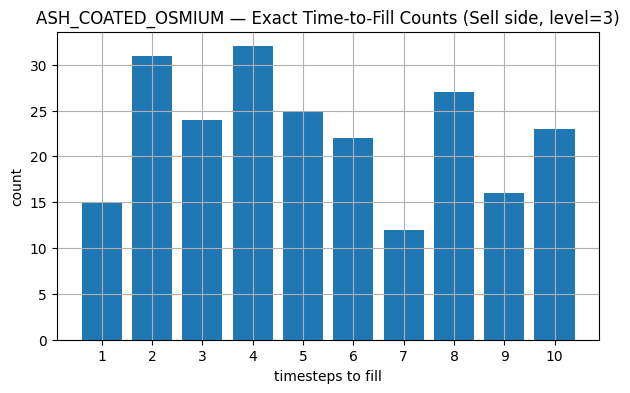

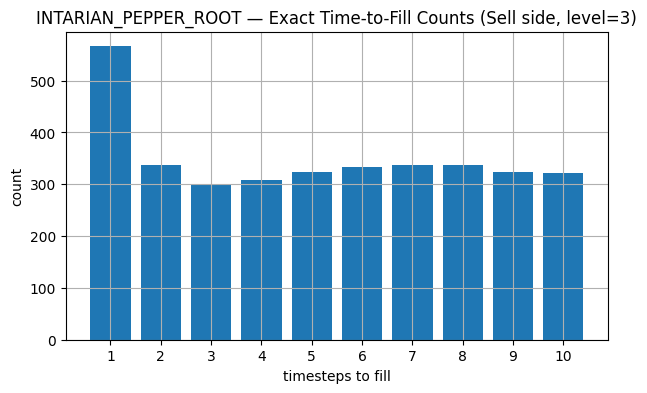

In [50]:
sell_fill_times = collect_fill_times(spread_df, level=3, max_horizon=10, side="sell")

for product, times in sell_fill_times.items():
    counts = pd.Series(times).value_counts().sort_index()

    plt.figure(figsize=(7, 4))
    plt.bar(counts.index, counts.values, width=0.8)
    plt.title(f"{product} — Exact Time-to-Fill Counts (Sell side, level=3)")
    plt.xlabel("timesteps to fill")
    plt.ylabel("count")
    plt.xticks(range(1, 11))
    plt.show()

In [45]:
def price_persistence(df: pd.DataFrame, level=2, horizon=5):
    results = []

    for product in df["product"].unique():
        sub = df[df["product"] == product].reset_index(drop=True)

        persistence = []

        for i in range(len(sub) - horizon):
            row = sub.iloc[i]
            bid = row["best_bid"]

            if pd.isna(bid):
                continue

            price = bid + level

            # check if price condition holds over multiple steps
            holds = 0
            for h in range(1, horizon + 1):
                if sub.iloc[i + h]["best_ask"] <= price:
                    holds += 1

            persistence.append(holds / horizon)

        results.append({
            "Product": product,
            "Avg Persistence": np.mean(persistence),
        })

    return pd.DataFrame(results)

persistence_df = price_persistence(spread_df, level=3)
display(persistence_df)

,Product,Avg Persistence
0,ASH_COATED_OSMIUM,0.000931
1,INTARIAN_PEPPER_ROOT,0.015322


## Inventory Dynamics

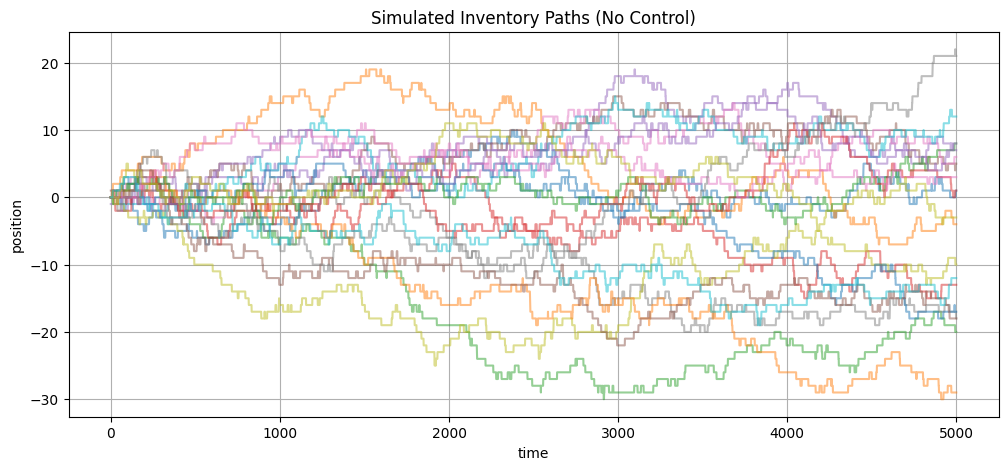

In [55]:
def simulate_inventory_paths(df, n_steps=5000, n_sim=20, fill_prob=0.01):
    paths = []

    for _ in range(n_sim):
        pos = 0
        trajectory = []

        for _ in range(n_steps):
            # simulate random fills (buy or sell)
            if np.random.rand() < fill_prob:
                pos += 1
            if np.random.rand() < fill_prob:
                pos -= 1

            trajectory.append(pos)

        paths.append(trajectory)

    return np.array(paths)

paths = simulate_inventory_paths(spread_df, fill_prob=0.02)

plt.figure(figsize=(12,5))
for p in paths:
    plt.plot(p, alpha=0.5)
plt.title("Simulated Inventory Paths (No Control)")
plt.xlabel("time")
plt.ylabel("position")
plt.show()

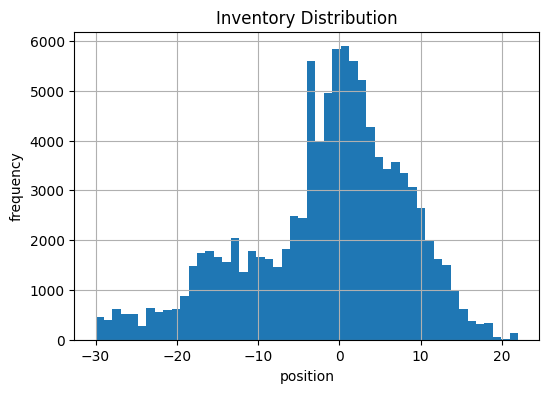

Mean: -1.51999
Std: 9.72426554552579
Max abs: 30


In [56]:
all_positions = paths.flatten()

plt.figure(figsize=(6,4))
plt.hist(all_positions, bins=50)
plt.title("Inventory Distribution")
plt.xlabel("position")
plt.ylabel("frequency")
plt.show()

print("Mean:", np.mean(all_positions))
print("Std:", np.std(all_positions))
print("Max abs:", np.max(np.abs(all_positions)))

In [57]:
def inventory_drift(paths):
    final_positions = paths[:, -1]
    return {
        "Mean Final Position": np.mean(final_positions),
        "Std Final Position": np.std(final_positions),
        "Max Abs Position": np.max(np.abs(final_positions)),
    }

inventory_drift(paths)

{'Mean Final Position': np.float64(-3.6),
 'Std Final Position': np.float64(12.63091445620625),
 'Max Abs Position': np.int64(29)}

In [58]:
def inventory_pnl_sensitivity(df):
    rows = []

    for product in df["product"].unique():
        sub = df[df["product"] == product].copy()

        returns = sub["mid"].diff().dropna()

        rows.append({
            "Product": product,
            "Return Std": returns.std(),
            "Avg Abs Return": returns.abs().mean(),
        })

    return pd.DataFrame(rows)

inventory_risk_df = inventory_pnl_sensitivity(spread_df)
display(inventory_risk_df)

,Product,Return Std,Avg Abs Return
0,ASH_COATED_OSMIUM,1.875374,1.221669
1,INTARIAN_PEPPER_ROOT,1.882215,1.154029


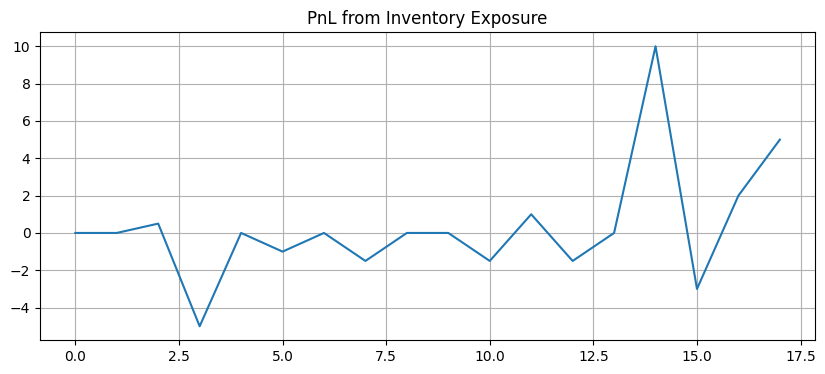

In [66]:
def simulate_inventory_pnl(df, steps=5000):
    sub = df[df["product"] == df["product"].iloc[0]].copy().reset_index(drop=True)

    pos = 0
    pnl = 0
    pnls = []

    for i in range(1, min(steps, len(sub))):
        # random fill
        if np.random.rand() < 0.02:
            pos += 1
        if np.random.rand() < 0.02:
            pos -= 1

        price_change = sub.iloc[i]["mid"] - sub.iloc[i-1]["mid"]
        pnl += pos * price_change
        pnls.append(pnl)

    return pnls

pnls = simulate_inventory_pnl(spread_df)

plt.figure(figsize=(10,4))
plt.plot(pnls)
plt.title("PnL from Inventory Exposure")
plt.show()

## Fill quality

In [71]:
def fill_quality_analysis_fixed(
    df: pd.DataFrame,
    level=3,
    max_wait=10,
    post_fill_horizon=1,
):
    rows = []

    for product in df["product"].unique():
        sub = df[df["product"] == product].copy().reset_index(drop=True)

        buy_pnls = []
        sell_pnls = []

        for i in range(len(sub) - max_wait - post_fill_horizon):
            row = sub.iloc[i]

            bid = row["best_bid"]
            ask = row["best_ask"]

            if pd.isna(bid) or pd.isna(ask):
                continue

            buy_price = bid + level
            sell_price = ask - level

            # -------- BUY SIDE --------
            buy_fill_time = None
            for h in range(1, max_wait + 1):
                future = sub.iloc[i + h]
                if pd.notna(future["best_ask"]) and future["best_ask"] <= buy_price:
                    buy_fill_time = i + h
                    break

            if buy_fill_time is not None:
                eval_idx = buy_fill_time + post_fill_horizon
                if eval_idx < len(sub):
                    eval_mid = sub.iloc[eval_idx]["mid"]
                    if pd.notna(eval_mid):
                        buy_pnls.append(eval_mid - buy_price)

            # -------- SELL SIDE --------
            sell_fill_time = None
            for h in range(1, max_wait + 1):
                future = sub.iloc[i + h]
                if pd.notna(future["best_bid"]) and future["best_bid"] >= sell_price:
                    sell_fill_time = i + h
                    break

            if sell_fill_time is not None:
                eval_idx = sell_fill_time + post_fill_horizon
                if eval_idx < len(sub):
                    eval_mid = sub.iloc[eval_idx]["mid"]
                    if pd.notna(eval_mid):
                        sell_pnls.append(sell_price - eval_mid)

        rows.append({
            "Product": product,
            "Buy Winrate": np.mean([p > 0 for p in buy_pnls]) if buy_pnls else np.nan,
            "Sell Winrate": np.mean([p > 0 for p in sell_pnls]) if sell_pnls else np.nan,
            "Avg Buy PnL": np.mean(buy_pnls) if buy_pnls else np.nan,
            "Avg Sell PnL": np.mean(sell_pnls) if sell_pnls else np.nan,
            "Median Buy PnL": np.median(buy_pnls) if buy_pnls else np.nan,
            "Median Sell PnL": np.median(sell_pnls) if sell_pnls else np.nan,
            "Num Buy Fills": len(buy_pnls),
            "Num Sell Fills": len(sell_pnls),
        })

    return pd.DataFrame(rows)

In [72]:
fq_1 = fill_quality_analysis_fixed(
    spread_df,
    level=3,
    max_wait=10,
    post_fill_horizon=1,
)
display(fq_1)

,Product,Buy Winrate,Sell Winrate,Avg Buy PnL,Avg Sell PnL,Median Buy PnL,Median Sell PnL,Num Buy Fills,Num Sell Fills
0,ASH_COATED_OSMIUM,0.109091,0.023474,-2.236364,-3.446009,-2.0,-3.0,220,213
1,INTARIAN_PEPPER_ROOT,0.913598,0.848448,3.423077,1.699662,4.0,3.0,2743,3253


In [73]:
fq_5 = fill_quality_analysis_fixed(
    spread_df,
    level=3,
    max_wait=10,
    post_fill_horizon=5,
)
display(fq_5)

,Product,Buy Winrate,Sell Winrate,Avg Buy PnL,Avg Sell PnL,Median Buy PnL,Median Sell PnL,Num Buy Fills,Num Sell Fills
0,ASH_COATED_OSMIUM,0.178082,0.051402,-2.262557,-3.324766,-2.0,-3.0,219,214
1,INTARIAN_PEPPER_ROOT,0.906169,0.834568,3.706502,1.264969,4.5,2.5,2707,3240


In [74]:
def plot_fill_pnl_distribution_fixed(
    df: pd.DataFrame,
    level=3,
    max_wait=10,
    post_fill_horizon=1,
    side="buy",
):
    for product in df["product"].unique():
        sub = df[df["product"] == product].copy().reset_index(drop=True)
        pnls = []

        for i in range(len(sub) - max_wait - post_fill_horizon):
            row = sub.iloc[i]

            bid = row["best_bid"]
            ask = row["best_ask"]

            if pd.isna(bid) or pd.isna(ask):
                continue

            if side == "buy":
                quote_price = bid + level
                fill_idx = None
                for h in range(1, max_wait + 1):
                    future = sub.iloc[i + h]
                    if pd.notna(future["best_ask"]) and future["best_ask"] <= quote_price:
                        fill_idx = i + h
                        break
                if fill_idx is not None:
                    eval_idx = fill_idx + post_fill_horizon
                    if eval_idx < len(sub):
                        eval_mid = sub.iloc[eval_idx]["mid"]
                        if pd.notna(eval_mid):
                            pnls.append(eval_mid - quote_price)

            elif side == "sell":
                quote_price = ask - level
                fill_idx = None
                for h in range(1, max_wait + 1):
                    future = sub.iloc[i + h]
                    if pd.notna(future["best_bid"]) and future["best_bid"] >= quote_price:
                        fill_idx = i + h
                        break
                if fill_idx is not None:
                    eval_idx = fill_idx + post_fill_horizon
                    if eval_idx < len(sub):
                        eval_mid = sub.iloc[eval_idx]["mid"]
                        if pd.notna(eval_mid):
                            pnls.append(quote_price - eval_mid)

        plt.figure(figsize=(6, 4))
        plt.hist(pnls, bins=40)
        plt.title(f"{product} — Fill PnL Distribution ({side.capitalize()}, post-fill horizon={post_fill_horizon})")
        plt.xlabel("PnL")
        plt.ylabel("frequency")
        plt.show()

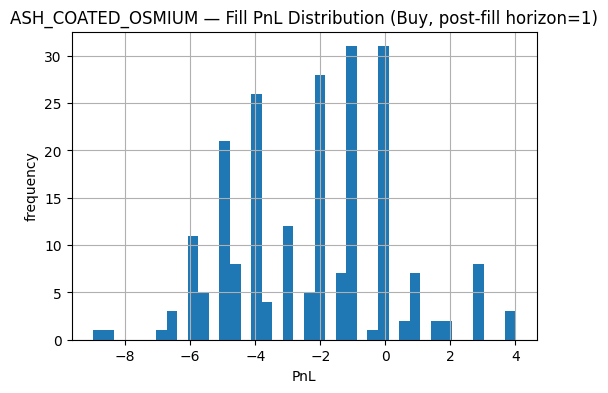

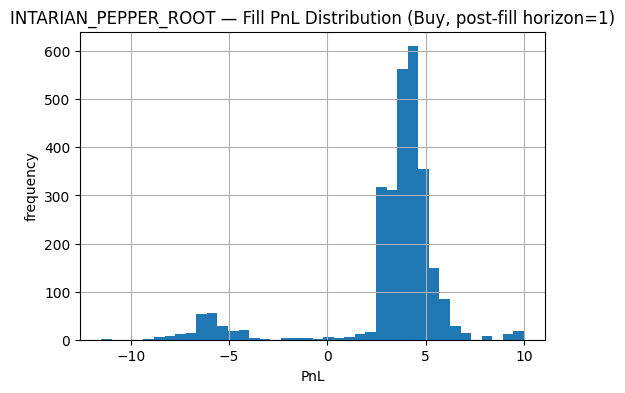

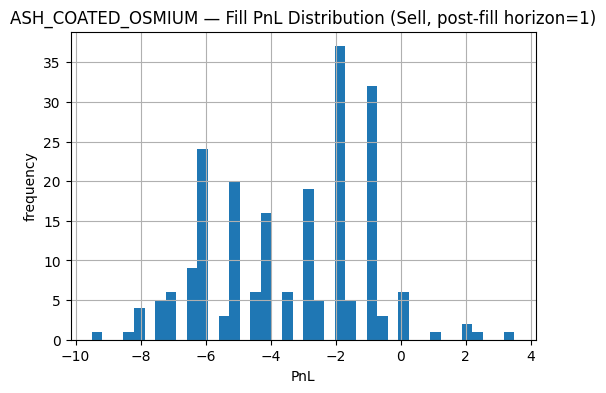

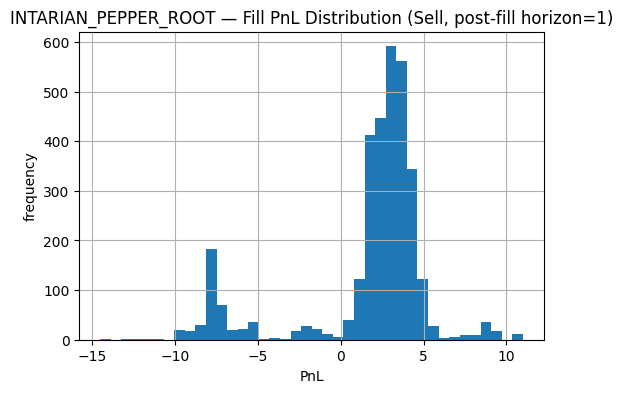

In [75]:
plot_fill_pnl_distribution_fixed(spread_df, level=3, max_wait=10, post_fill_horizon=1, side="buy")
plot_fill_pnl_distribution_fixed(spread_df, level=3, max_wait=10, post_fill_horizon=1, side="sell")

## Short-term predictability

In [80]:
def get_clean_returns(df_product: pd.DataFrame) -> pd.Series:
    sub = df_product.copy().sort_values("global_ts")
    returns = sub["mid"].diff()
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()
    return returns

In [81]:
def compute_autocorrelation_fixed(df: pd.DataFrame, lags=10):
    rows = []

    for product in df["product"].unique():
        sub = df[df["product"] == product].copy()
        returns = get_clean_returns(sub)

        for lag in range(1, lags + 1):
            corr = returns.autocorr(lag=lag)
            rows.append({
                "Product": product,
                "Lag": lag,
                "Autocorrelation": corr
            })

    return pd.DataFrame(rows)

autocorr_df = compute_autocorrelation_fixed(spread_df, lags=10)
display(autocorr_df)

,Product,Lag,Autocorrelation
0,ASH_COATED_OSMIUM,1,-0.442114
1,ASH_COATED_OSMIUM,2,-0.005221
2,ASH_COATED_OSMIUM,3,-0.000167
3,ASH_COATED_OSMIUM,4,0.001947
4,ASH_COATED_OSMIUM,5,-0.005676
5,ASH_COATED_OSMIUM,6,0.004935
6,ASH_COATED_OSMIUM,7,0.001366
7,ASH_COATED_OSMIUM,8,-0.005726
8,ASH_COATED_OSMIUM,9,0.008739
9,ASH_COATED_OSMIUM,10,-0.003268


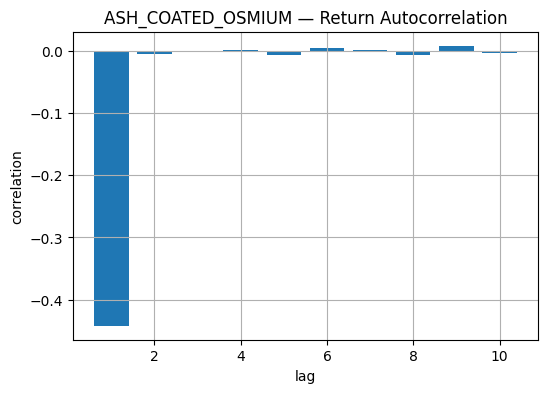

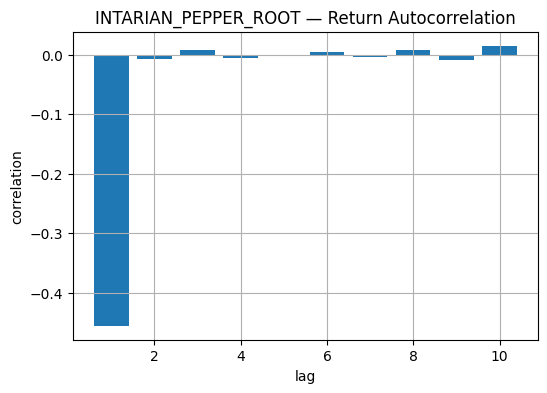

In [82]:
for product in autocorr_df["Product"].unique():
    sub = autocorr_df[autocorr_df["Product"] == product]

    plt.figure(figsize=(6,4))
    plt.bar(sub["Lag"], sub["Autocorrelation"])
    plt.title(f"{product} — Return Autocorrelation")
    plt.xlabel("lag")
    plt.ylabel("correlation")
    plt.show()

In [83]:
def trend_persistence_fixed(df: pd.DataFrame):
    rows = []

    for product in df["product"].unique():
        sub = df[df["product"] == product].copy()
        returns = get_clean_returns(sub)

        same_direction = []

        for i in range(len(returns) - 1):
            r1 = returns.iloc[i]
            r2 = returns.iloc[i + 1]

            if r1 == 0 or r2 == 0:
                continue

            same_direction.append(int(np.sign(r1) == np.sign(r2)))

        rows.append({
            "Product": product,
            "Trend Persistence": np.mean(same_direction) if same_direction else np.nan,
            "Num Comparisons": len(same_direction),
        })

    return pd.DataFrame(rows)

trend_df = trend_persistence_fixed(spread_df)
display(trend_df)

,Product,Trend Persistence,Num Comparisons
0,ASH_COATED_OSMIUM,0.264830,12812
1,INTARIAN_PEPPER_ROOT,0.253995,10138


In [84]:
def conditional_drift_fixed(df: pd.DataFrame):
    rows = []

    for product in df["product"].unique():
        sub = df[df["product"] == product].copy()
        returns = get_clean_returns(sub).reset_index(drop=True)

        up_next = []
        down_next = []

        for i in range(len(returns) - 1):
            r_now = returns.iloc[i]
            r_next = returns.iloc[i + 1]

            if r_now > 0:
                up_next.append(r_next)
            elif r_now < 0:
                down_next.append(r_next)

        rows.append({
            "Product": product,
            "Next Return After Up": np.mean(up_next) if up_next else np.nan,
            "Next Return After Down": np.mean(down_next) if down_next else np.nan,
            "Num Up Cases": len(up_next),
            "Num Down Cases": len(down_next),
        })

    return pd.DataFrame(rows)

cond_df = conditional_drift_fixed(spread_df)
display(cond_df)

,Product,Next Return After Up,Next Return After Down,Num Up Cases,Num Down Cases
0,ASH_COATED_OSMIUM,-0.765821,0.804267,8675,8647
1,INTARIAN_PEPPER_ROOT,-0.627553,1.125473,8961,6336


## ASH specific investigation

In [89]:
def collect_ash_buy_fills(
    df: pd.DataFrame,
    level=3,
    max_wait=10,
    post_fill_horizon=1,
):
    sub = df[df["product"] == "ASH_COATED_OSMIUM"].copy().sort_values("global_ts").reset_index(drop=True)

    records = []

    for i in range(len(sub) - max_wait - post_fill_horizon):
        row = sub.iloc[i]

        bid = row["best_bid"]
        ask = row["best_ask"]
        mid = row["mid"]
        spread = row["spread"]

        if pd.isna(bid) or pd.isna(ask) or pd.isna(mid) or pd.isna(spread):
            continue

        quote_price = bid + level

        fill_idx = None
        for h in range(1, max_wait + 1):
            future = sub.iloc[i + h]
            if pd.notna(future["best_ask"]) and future["best_ask"] <= quote_price:
                fill_idx = i + h
                break

        if fill_idx is None:
            continue

        eval_idx = fill_idx + post_fill_horizon
        if eval_idx >= len(sub):
            continue

        eval_mid = sub.iloc[eval_idx]["mid"]
        if pd.isna(eval_mid):
            continue

        prev_ret = np.nan
        if i >= 1:
            prev_mid = sub.iloc[i - 1]["mid"]
            if pd.notna(prev_mid) and pd.notna(mid):
                prev_ret = mid - prev_mid

        records.append({
            "start_idx": i,
            "fill_idx": fill_idx,
            "wait_time": fill_idx - i,
            "quote_price": quote_price,
            "spread": spread,
            "start_mid": mid,
            "prev_ret": prev_ret,
            "eval_mid": eval_mid,
            "pnl": eval_mid - quote_price,
        })

    return pd.DataFrame(records)

In [90]:
ash_fills = collect_ash_buy_fills(spread_df, level=3, max_wait=10, post_fill_horizon=1)
display(ash_fills.head())
print("Num fills:", len(ash_fills))

,start_idx,fill_idx,wait_time,quote_price,spread,start_mid,prev_ret,eval_mid,pnl
0,69,76,7,9995.0,11.0,9997.5,2.5,9995.0,0.0
1,91,94,3,9997.0,10.0,9999.0,4.5,9996.0,-1.0
2,215,223,8,10001.0,10.0,10003.0,2.0,9999.0,-2.0
3,227,232,5,10000.0,10.0,10002.0,NaN,9998.0,-2.0
4,432,442,10,9996.0,16.0,10001.0,1.0,10000.0,4.0


Num fills: 220


In [91]:
def ash_fill_quality_by_spread_fixed(fills: pd.DataFrame):
    tmp = fills.copy()

    tmp["Spread Bucket"] = pd.cut(
        tmp["spread"],
        bins=[-np.inf, 10, 15, np.inf],
        labels=["spread ≤ 10", "10 < spread ≤ 15", "spread > 15"]
    )

    out = (
        tmp.groupby("Spread Bucket", observed=False)["pnl"]
        .agg(["count", "mean", "median"])
        .reset_index()
        .rename(columns={"count": "Num Fills", "mean": "Avg PnL", "median": "Median PnL"})
    )
    return out

ash_spread_df = ash_fill_quality_by_spread_fixed(ash_fills)
display(ash_spread_df)

,Spread Bucket,Num Fills,Avg PnL,Median PnL
0,spread ≤ 10,145,-3.331034,-4.0
1,10 < spread ≤ 15,62,-0.774194,-1.0
2,spread > 15,13,3.000000,3.0


In [92]:
def ash_fill_quality_vs_momentum_fixed(fills: pd.DataFrame):
    tmp = fills.copy()

    tmp = tmp[pd.notna(tmp["prev_ret"])].copy()

    def label_ret(x):
        if x > 0:
            return "After Up Move"
        elif x < 0:
            return "After Down Move"
        return "After Flat Move"

    tmp["Momentum Bucket"] = tmp["prev_ret"].apply(label_ret)

    out = (
        tmp.groupby("Momentum Bucket")["pnl"]
        .agg(["count", "mean", "median"])
        .reset_index()
        .rename(columns={"count": "Num Fills", "mean": "Avg PnL", "median": "Median PnL"})
    )
    return out

ash_momentum_df = ash_fill_quality_vs_momentum_fixed(ash_fills)
display(ash_momentum_df)

,Momentum Bucket,Num Fills,Avg PnL,Median PnL
0,After Down Move,5,0.600000,0.0
1,After Flat Move,4,3.250000,3.0
2,After Up Move,193,-2.419689,-2.0


In [93]:
def ash_fill_quality_vs_wait_fixed(fills: pd.DataFrame):
    tmp = fills.copy()

    tmp["Wait Bucket"] = np.where(tmp["wait_time"] <= 3, "Early fills (≤3)", "Late fills (>3)")

    out = (
        tmp.groupby("Wait Bucket")["pnl"]
        .agg(["count", "mean", "median"])
        .reset_index()
        .rename(columns={"count": "Num Fills", "mean": "Avg PnL", "median": "Median PnL"})
    )
    return out

ash_wait_df = ash_fill_quality_vs_wait_fixed(ash_fills)
display(ash_wait_df)

,Wait Bucket,Num Fills,Avg PnL,Median PnL
0,Early fills (≤3),47,-2.425532,-2.0
1,Late fills (>3),173,-2.184971,-2.0


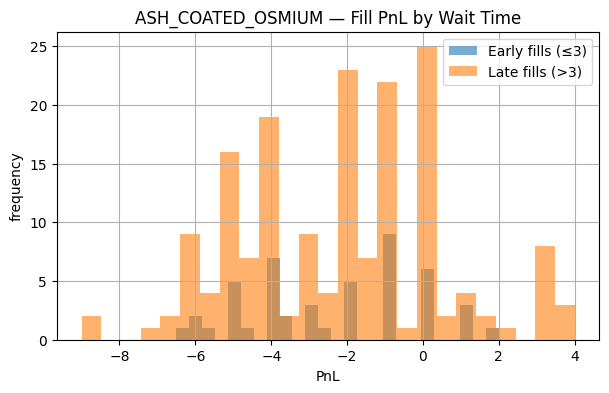

In [94]:
plt.figure(figsize=(7, 4))
plt.hist(ash_fills.loc[ash_fills["wait_time"] <= 3, "pnl"], bins=25, alpha=0.6, label="Early fills (≤3)")
plt.hist(ash_fills.loc[ash_fills["wait_time"] > 3, "pnl"], bins=25, alpha=0.6, label="Late fills (>3)")
plt.title("ASH_COATED_OSMIUM — Fill PnL by Wait Time")
plt.xlabel("PnL")
plt.ylabel("frequency")
plt.legend()
plt.show()

## Market access

In [95]:
# Put in your own observed Round 2 trading PnL here
# ideally use the pure algo PnL from your current submission
round2_backtest_pnl = 6746  # <- replace

# Full access is 100% vs default 80%, so quote flow multiplier is 1.25
linear_upper_bound = 0.25 * round2_backtest_pnl

print("Linear upper-bound value of market access:", linear_upper_bound)

Linear upper-bound value of market access: 1686.5


In [96]:
# Replace these with your own rough per-product PnL estimates from logs/backtests
pepper_pnl = 5890   # <- estimated PnL contribution from INTARIAN_PEPPER_ROOT
ash_pnl = 900      # <- estimated PnL contribution from ASH_COATED_OSMIUM

# Scaling assumptions:
# Pepper: likely scales relatively well with extra quotes
# Ash: extra quotes less useful due to adverse selection / filtering
pepper_scale = 0.8   # 80% of linear 25% uplift
ash_scale = 0.2      # only 20% of linear 25% uplift

delta_pepper = 0.25 * pepper_pnl * pepper_scale
delta_ash = 0.25 * ash_pnl * ash_scale

adjusted_market_access_value = delta_pepper + delta_ash

print("Estimated Pepper contribution:", delta_pepper)
print("Estimated Ash contribution:", delta_ash)
print("Adjusted market access value:", adjusted_market_access_value)

Estimated Pepper contribution: 1178.0
Estimated Ash contribution: 45.0
Adjusted market access value: 1223.0


In [97]:
scenarios = pd.DataFrame({
    "Pepper scale": [0.7, 0.8, 0.9],
    "Ash scale":    [0.0, 0.1, 0.2],
})

values = []
for _, row in scenarios.iterrows():
    val = 0.25 * pepper_pnl * row["Pepper scale"] + 0.25 * ash_pnl * row["Ash scale"]
    values.append(val)

scenarios["Estimated access value"] = values
display(scenarios)

,Pepper scale,Ash scale,Estimated access value
0,0.7,0.0,1030.75
1,0.8,0.1,1200.50
2,0.9,0.2,1370.25


In [98]:
market_access_value = adjusted_market_access_value  # or choose a scenario from above

max_rational_bid = market_access_value
safe_bid = 0.6 * market_access_value
medium_bid = 0.75 * market_access_value
aggressive_bid = 0.9 * market_access_value

print("Max rational bid:", round(max_rational_bid, 2))
print("Safe bid:", round(safe_bid, 2))
print("Medium bid:", round(medium_bid, 2))
print("Aggressive bid:", round(aggressive_bid, 2))

Max rational bid: 1223.0
Safe bid: 733.8
Medium bid: 917.25
Aggressive bid: 1100.7
